# SPI/AI Statistical Analysis

This notebook performs the statistical analysis described in `proposal_revised.txt` using the tehsil-level results produced by `spi_ai_calculation.ipynb`.

Primary analysis uses the current outputs:
- `data/processed/spi_index.tif`
- `data/processed/ai_index.tif`
- `data/processed/tehsil_spi_ai_zonal_stats.csv`
- `data/interim/tehsils_aoi_32643.gpkg`

The notebook also derives component zonal statistics from the source rasters for proposal-style component contribution and sensitivity checks.

In [1]:
# Imports and configuration
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from libpysal.weights import Queen
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran, Moran_Local
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.gofplots import qqplot

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

root = Path.cwd()
if root.name != 'spi_gb_north':
    candidates = [root / 'spi_gb_north', root / 'sds' / 'spi_gb_north']
    root = next((p for p in candidates if p.exists()), root)

processed = root / 'data' / 'processed'
interim = root / 'data' / 'interim'
outputs = root / 'outputs' / 'statistical_analysis'
outputs.mkdir(parents=True, exist_ok=True)

paths = {
    'tehsils': interim / 'tehsils_aoi_32643.gpkg',
    'zonal': processed / 'tehsil_spi_ai_zonal_stats.csv',
    'spi': processed / 'spi_index.tif',
    'ai': processed / 'ai_index.tif',
    'tri': interim / 'tri_32643_100m.tif',
    'forest': interim / 'forest_mask_32643_100m.tif',
    'water': interim / 'water_mask_32643_100m.tif',
    'snow': interim / 'snow_aligned_32643_100m' / 'snow_frequency_aligned_32643_100m.tif',
}

missing = [f'{k}: {v}' for k, v in paths.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

print(f'Project root: {root}')
print(f'Output directory: {outputs}')
print('Using libpysal/esda/statsmodels for spatial and regression statistics')

C:\Users\AtifA\miniconda3\envs\sds\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


C:\Users\AtifA\miniconda3\envs\sds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north
Output directory: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis
Using libpysal/esda/statsmodels for spatial and regression statistics


## 1. Load Tehsil-Level SPI/AI Results

The proposal uses tehsils as the unit of analysis. Here, tehsil geometries are joined to the zonal SPI/AI results generated from the final rasters.

In [2]:
def norm_name(value):
    return str(value).upper().strip()

gdf = gpd.read_file(paths['tehsils'])
zonal = pd.read_csv(paths['zonal'])

gdf['tehsil_key'] = gdf['shapeName'].map(norm_name)
zonal['tehsil_key'] = zonal['tehsil'].map(norm_name)

analysis_gdf = gdf.merge(zonal, on='tehsil_key', how='left')
analysis_gdf['tehsil'] = analysis_gdf['tehsil'].fillna(analysis_gdf['shapeName'])

# Keep units with both SPI and AI values from the current raster outputs.
analysis_gdf = analysis_gdf.dropna(subset=['spi_mean', 'ai_mean']).copy()
analysis_gdf['area_km2'] = analysis_gdf.to_crs(analysis_gdf.crs).geometry.area / 1e6
analysis_gdf['spi'] = analysis_gdf['spi_mean']
analysis_gdf['ai'] = analysis_gdf['ai_mean']

print(f'Tehsils in geometry file: {len(gdf)}')
print(f'Tehsils with SPI/AI results: {len(analysis_gdf)}')
print(f'CRS: {analysis_gdf.crs}')
display(analysis_gdf[['tehsil', 'area_km2', 'spi_mean', 'ai_mean', 'spi_count', 'ai_count']].head())

Tehsils in geometry file: 81
Tehsils with SPI/AI results: 81
CRS: EPSG:32643


,tehsil,area_km2,spi_mean,ai_mean,spi_count,ai_count
0,BAGH,449.276994,-0.103081,0.866644,44829,44935
1,DHEERKOT,230.172839,-0.366219,0.846837,21920,23006
2,BARNALA,425.760029,-0.666979,0.948007,40034,42574
3,BHIMBER,372.166558,-0.475282,0.836280,35951,37207
4,SAMAHNI,398.290899,-0.392897,0.943445,38294,39832


## 2. Helper Functions

The statistical calculations in this notebook use `libpysal`/`esda` for Queen contiguity, Moran's I, and LISA, and `statsmodels` for OLS regression and diagnostics. The helper functions below only handle z-scores, LISA labeling, and figure saving.

In [3]:
def zscore(s):
    s = pd.Series(s, dtype='float64')
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd


def lisa_cluster_labels(local, alpha=0.10):
    """Convert esda.Moran_Local quadrants to HH/LL/HL/LH labels."""
    quadrant_labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    labels = []
    for q, p in zip(local.q, local.p_sim):
        labels.append(quadrant_labels.get(int(q), 'Not Significant') if p <= alpha else 'Not Significant')
    return labels


def savefig(name):
    path = outputs / name
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

## 3. Descriptive Statistics and Distributions

This summarizes the tehsil-level distributions used in the proposal's regression, priority, and spatial clustering analysis.

,count,mean,std,min,25%,50%,75%,max
spi,81.0,-2.309779e-01,0.314252,-0.912927,-0.454805,-0.223065,0.055781,0.292233
ai,81.0,6.960720e-01,0.247987,0.178879,0.473613,0.812205,0.903806,0.958507
spi_z,81.0,3.141242e-17,1.006231,-2.183588,-0.716692,0.025337,0.918198,1.675313
ai_z,81.0,1.603655e-16,1.006231,-2.098560,-0.902650,0.471220,0.842901,1.064854
gap_index,81.0,-1.507710e-16,1.865869,-3.247125,-1.555376,-0.354704,1.681847,3.481065
area_km2,81.0,1.557921e+03,2132.905985,16.665564,286.532344,572.530683,1972.763490,10801.975097


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\01_distributions.png


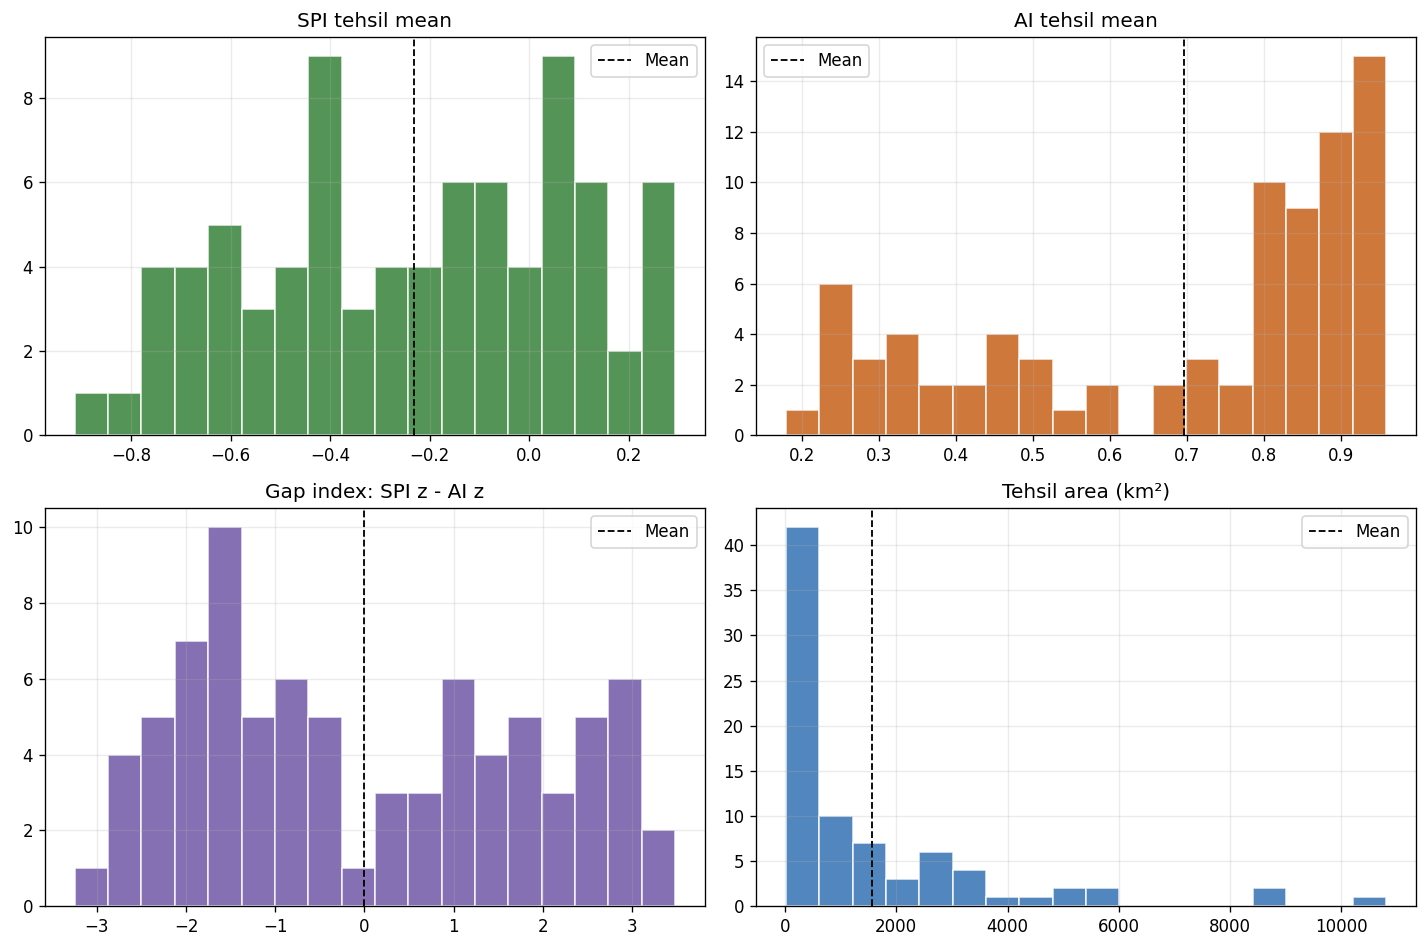

In [4]:
analysis_gdf['spi_z'] = zscore(analysis_gdf['spi'])
analysis_gdf['ai_z'] = zscore(analysis_gdf['ai'])
analysis_gdf['gap_index'] = analysis_gdf['spi_z'] - analysis_gdf['ai_z']
analysis_gdf['gap_rank'] = analysis_gdf['gap_index'].rank(ascending=False, method='min').astype(int)

summary = analysis_gdf[['spi', 'ai', 'spi_z', 'ai_z', 'gap_index', 'area_km2']].describe().T
summary.to_csv(outputs / 'descriptive_statistics.csv')
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col, title, color in [
    (axes[0], 'spi', 'SPI tehsil mean', '#2E7D32'),
    (axes[1], 'ai', 'AI tehsil mean', '#C55A11'),
    (axes[2], 'gap_index', 'Gap index: SPI z - AI z', '#6A51A3'),
    (axes[3], 'area_km2', 'Tehsil area (km²)', '#2B6CB0'),
]:
    ax.hist(analysis_gdf[col].dropna(), bins=18, color=color, alpha=0.82, edgecolor='white')
    ax.axvline(analysis_gdf[col].mean(), color='black', linestyle='--', linewidth=1.1, label='Mean')
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
savefig('01_distributions.png')
plt.show()

## 4. Choropleth Maps: SPI, AI, and Gap

The gap index is high where scenic potential is above average and accessibility is below average.

Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\02_spi_ai_gap_maps.png


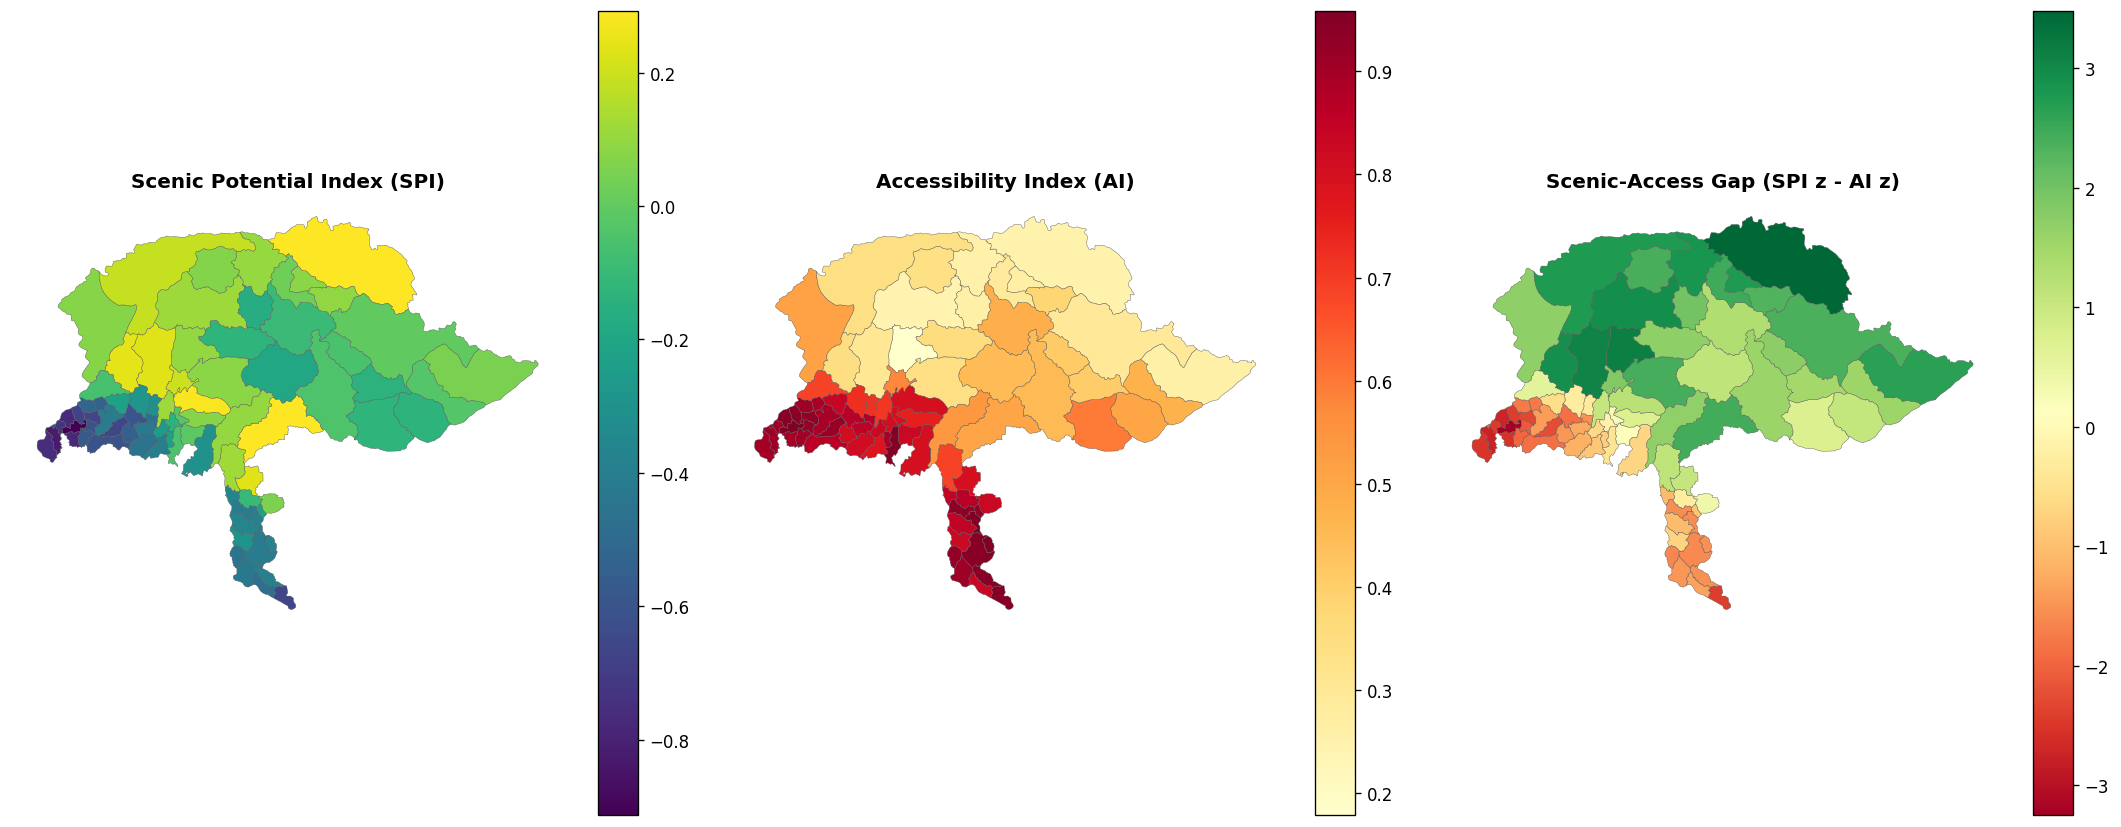

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
map_specs = [
    ('spi', 'Scenic Potential Index (SPI)', 'viridis'),
    ('ai', 'Accessibility Index (AI)', 'YlOrRd'),
    ('gap_index', 'Scenic-Access Gap (SPI z - AI z)', 'RdYlGn'),
]
for ax, (col, title, cmap) in zip(axes, map_specs):
    analysis_gdf.plot(column=col, cmap=cmap, linewidth=0.25, edgecolor='0.35', legend=True, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_axis_off()
plt.tight_layout()
savefig('02_spi_ai_gap_maps.png')
plt.show()

## 5. Queen Contiguity Spatial Weights

The proposal specifies first-order Queen contiguity. The table reports neighbor counts and flags any fallback nearest-neighbor links if isolated units occur.

In [6]:
analysis_gdf = analysis_gdf.reset_index(drop=True)

# libpysal Queen contiguity, row-standardized as specified in the proposal.
w = Queen.from_dataframe(analysis_gdf, use_index=False)
if w.islands:
    print(f'Warning: Queen weights contain isolated units: {w.islands}')
w.transform = 'r'

analysis_gdf['queen_neighbors'] = [len(w.neighbors[i]) for i in range(len(analysis_gdf))]
neighbor_summary = analysis_gdf['queen_neighbors'].describe().to_frame('queen_neighbor_count')
neighbor_summary.to_csv(outputs / 'queen_neighbor_summary.csv')
display(neighbor_summary)
print('Neighbor count range:', int(analysis_gdf['queen_neighbors'].min()), 'to', int(analysis_gdf['queen_neighbors'].max()))
print('Mean neighbors:', analysis_gdf['queen_neighbors'].mean().round(2))

,queen_neighbor_count
count,81.000000
mean,4.716049
std,1.704660
min,1.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,9.000000


Neighbor count range: 1 to 9
Mean neighbors: 4.72


## 6. Global Spatial Autocorrelation: Moran's I

Moran's I is calculated for SPI, AI, and the scenic-access gap using 999 random permutations.

,variable,I,expected_I,z_score,p_value,sim_mean,sim_std
0,SPI,0.809721,-0.0125,11.249014,0.001,-0.012666,0.073144
1,AI,0.889273,-0.0125,11.858816,0.001,-0.009481,0.075826
2,Gap index,0.883591,-0.0125,11.474156,0.001,-0.011117,0.078015


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\03_global_moran.png


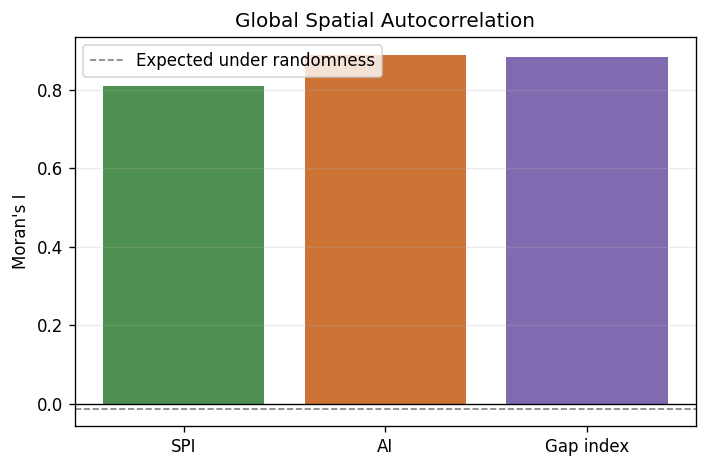

In [7]:
global_rows = []
for label, col in [('SPI', 'spi'), ('AI', 'ai'), ('Gap index', 'gap_index')]:
    moran = Moran(analysis_gdf[col].to_numpy(), w, permutations=999, two_tailed=True)
    global_rows.append({
        'variable': label,
        'I': float(moran.I),
        'expected_I': float(moran.EI),
        'z_score': float(moran.z_sim),
        'p_value': float(moran.p_sim),
        'sim_mean': float(np.mean(moran.sim)),
        'sim_std': float(np.std(moran.sim, ddof=1)),
    })

global_moran = pd.DataFrame(global_rows)
global_moran.to_csv(outputs / 'global_moran_summary.csv', index=False)
display(global_moran)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2E7D32', '#C55A11', '#6A51A3']
ax.bar(global_moran['variable'], global_moran['I'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(global_moran['expected_I'].iloc[0], color='gray', linestyle='--', linewidth=1, label='Expected under randomness')
ax.set_ylabel("Moran's I")
ax.set_title("Global Spatial Autocorrelation")
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
savefig('03_global_moran.png')
plt.show()

## 7. Local Spatial Clustering: LISA

Local Moran's I classifies each tehsil as HH, LL, HL, LH, or not significant. The proposal recommends `p < 0.10` for local clustering with moderate sample sizes.

,cluster,count,variable
0,Not Significant,31,SPI
1,HH,28,SPI
2,LL,21,SPI
3,LH,1,SPI
4,HH,32,AI
5,LL,27,AI
6,Not Significant,22,AI
7,Not Significant,28,Gap
8,HH,27,Gap
9,LL,26,Gap


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\04_lisa_cluster_maps.png


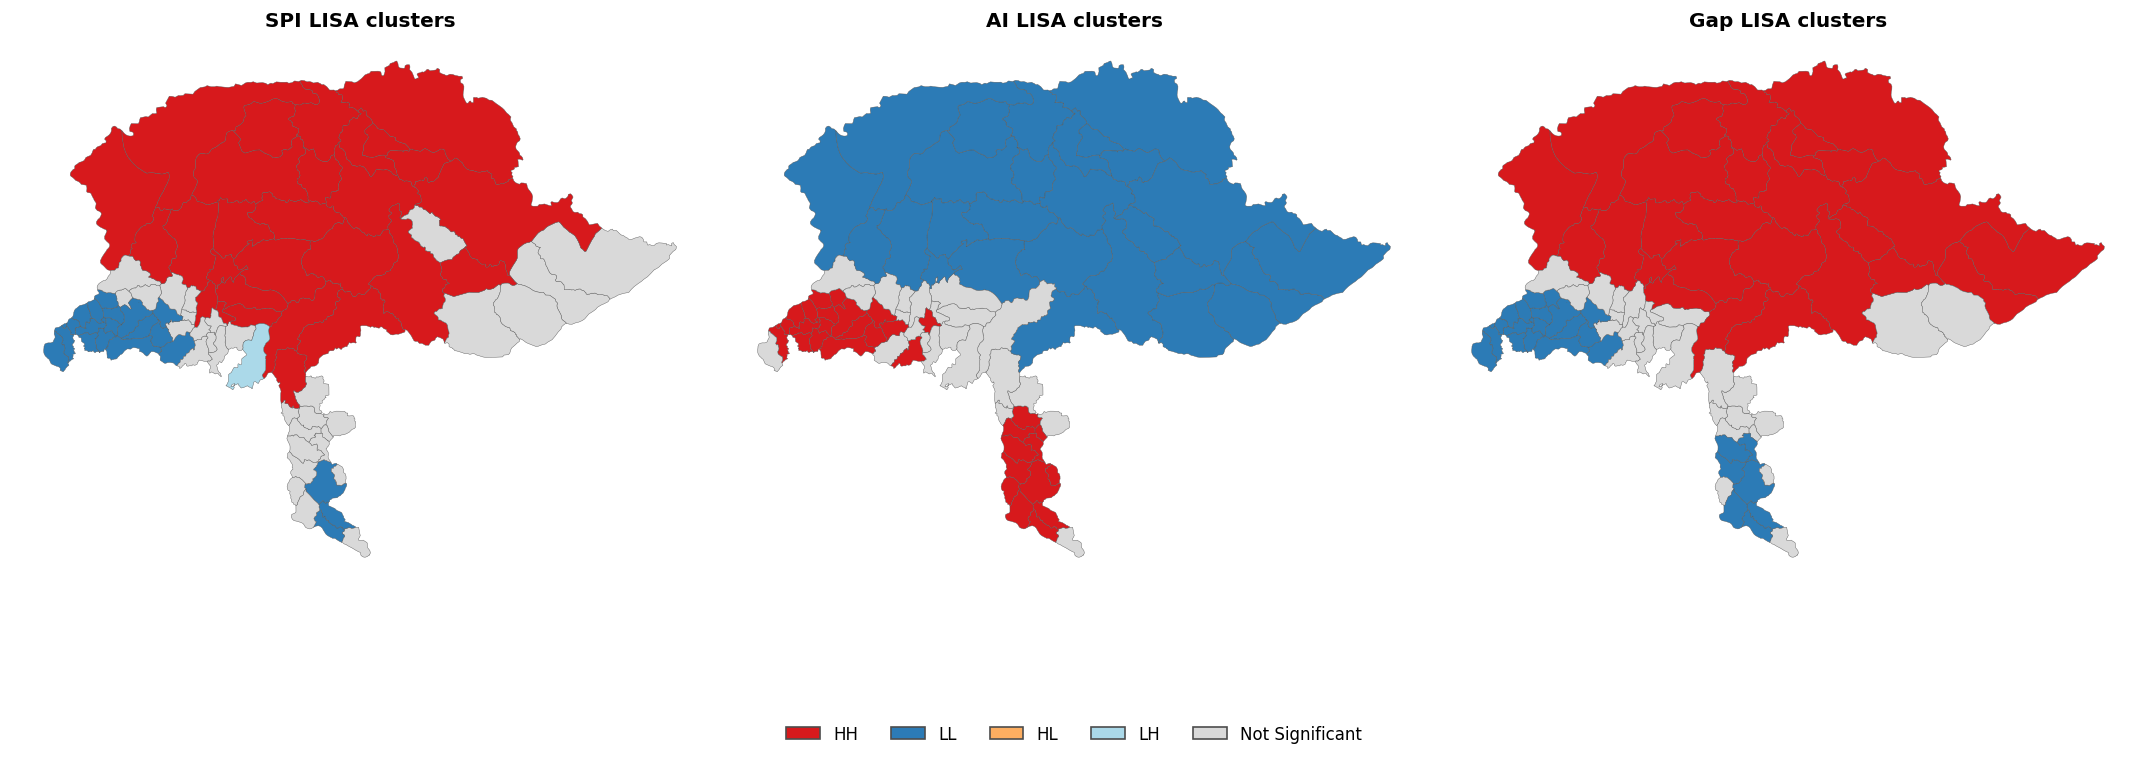

In [8]:
ALPHA_LISA = 0.10
for col, prefix in [('spi', 'spi'), ('ai', 'ai'), ('gap_index', 'gap')]:
    values = analysis_gdf[col].to_numpy()
    values_z = zscore(values).to_numpy()
    local = Moran_Local(values, w, permutations=999)
    analysis_gdf[f'{prefix}_local_I'] = local.Is
    analysis_gdf[f'{prefix}_spatial_lag'] = lag_spatial(w, values_z)
    analysis_gdf[f'{prefix}_local_p'] = local.p_sim
    analysis_gdf[f'{prefix}_quadrant'] = local.q
    analysis_gdf[f'{prefix}_cluster'] = lisa_cluster_labels(local, alpha=ALPHA_LISA)

cluster_counts = []
for prefix, label in [('spi', 'SPI'), ('ai', 'AI'), ('gap', 'Gap')]:
    counts = analysis_gdf[f'{prefix}_cluster'].value_counts().rename_axis('cluster').reset_index(name='count')
    counts['variable'] = label
    cluster_counts.append(counts)
cluster_counts = pd.concat(cluster_counts, ignore_index=True)
cluster_counts.to_csv(outputs / 'lisa_cluster_counts.csv', index=False)
display(cluster_counts)

cluster_palette = {
    'HH': '#d7191c',
    'LL': '#2c7bb6',
    'HL': '#fdae61',
    'LH': '#abd9e9',
    'Not Significant': '#d9d9d9',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, prefix, title in zip(axes, ['spi', 'ai', 'gap'], ['SPI LISA clusters', 'AI LISA clusters', 'Gap LISA clusters']):
    colors = analysis_gdf[f'{prefix}_cluster'].map(cluster_palette)
    analysis_gdf.assign(_color=colors).plot(color=colors, linewidth=0.25, edgecolor='0.35', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_axis_off()
legend_handles = [Patch(facecolor=color, edgecolor='0.3', label=label) for label, color in cluster_palette.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
savefig('04_lisa_cluster_maps.png')
plt.show()

## 8. Regression Analysis: SPI ~ AI

The proposal's primary model asks whether accessibility meaningfully predicts scenic potential variation. This section fits OLS, reports diagnostics, and tests residual spatial autocorrelation.

In [9]:
X = sm.add_constant(analysis_gdf['ai'].astype(float))
y = analysis_gdf['spi'].astype(float)
model = sm.OLS(y, X).fit()

resid_moran_obj = Moran(model.resid.to_numpy(), w, permutations=999, two_tailed=True)
bp_lm, bp_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(model.resid, model.model.exog)
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)
pearson_r = analysis_gdf[['ai', 'spi']].corr(method='pearson').iloc[0, 1]
spearman_rho = analysis_gdf[['ai', 'spi']].corr(method='spearman').iloc[0, 1]

regression_summary = pd.DataFrame({
    'metric': [
        'n', 'intercept', 'ai_coefficient', 'ai_p_value', 'r_squared', 'adj_r_squared',
        'f_statistic', 'f_p_value', 'residual_sigma', 'pearson_r', 'spearman_rho',
        'residual_moran_i', 'residual_moran_p', 'breusch_pagan_lm', 'breusch_pagan_p',
        'jarque_bera_stat', 'jarque_bera_p', 'residual_skew', 'residual_kurtosis'
    ],
    'value': [
        len(analysis_gdf), model.params['const'], model.params['ai'], model.pvalues['ai'],
        model.rsquared, model.rsquared_adj, model.fvalue, model.f_pvalue,
        float(np.sqrt(model.mse_resid)), pearson_r, spearman_rho,
        float(resid_moran_obj.I), float(resid_moran_obj.p_sim),
        float(bp_lm), float(bp_pvalue), float(jb_stat), float(jb_pvalue), float(skew), float(kurtosis)
    ]
})
regression_summary.to_csv(outputs / 'ols_regression_summary.csv', index=False)
display(regression_summary)

display(model.summary())
analysis_gdf['ols_fitted_spi'] = model.fittedvalues
analysis_gdf['ols_residual'] = model.resid

,metric,value
0,n,8.100000e+01
1,intercept,4.034455e-01
2,ai_coefficient,-9.114335e-01
3,ai_p_value,3.934858e-14
4,r_squared,5.173093e-01
5,adj_r_squared,5.111993e-01
6,f_statistic,8.466589e+01
7,f_p_value,3.934858e-14
8,residual_sigma,2.197072e-01
9,pearson_r,-7.192422e-01


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spi   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     84.67
Date:                Fri, 15 May 2026   Prob (F-statistic):           3.93e-14
Time:                        20:25:38   Log-Likelihood:                 8.8307
No. Observations:                  81   AIC:                            -13.66
Df Residuals:                      79   BIC:                            -8.873
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4034      0.073      5.516      0.000       0.258       0.549
ai            -0.9114      0.099     -9.201      0.000      -1.109      -0.714
==============================================================================
Omnibus:                        4.070   Durbin-Watson:                   0.984
Prob(Omnibus):                  0.131   Jarque-Bera (JB):                3.644
Skew:                           0.518   Prob(JB):                        0.162
Kurtosis:                       3.070   Cond. No.                         6.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\05_ols_diagnostics.png


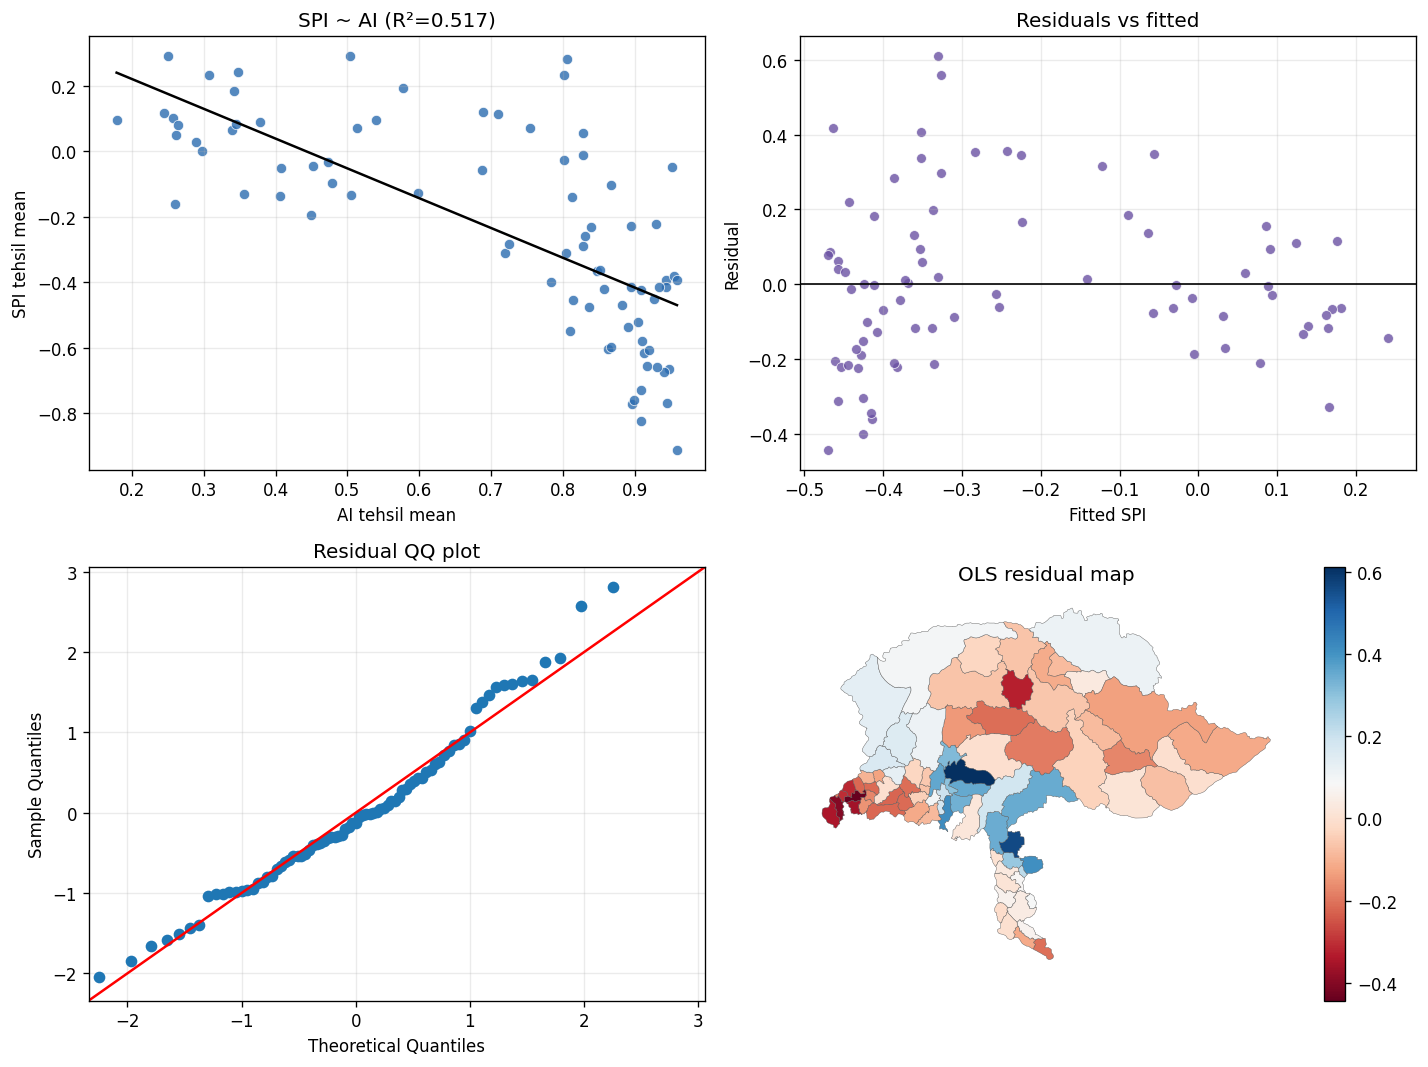

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Scatter with fitted line
ax = axes[0, 0]
ax.scatter(analysis_gdf['ai'], analysis_gdf['spi'], s=38, alpha=0.8, color='#2B6CB0', edgecolor='white', linewidth=0.5)
x_line = np.linspace(analysis_gdf['ai'].min(), analysis_gdf['ai'].max(), 100)
y_line = model.params['const'] + model.params['ai'] * x_line
ax.plot(x_line, y_line, color='black', linewidth=1.5)
ax.set_title(f'SPI ~ AI (R²={model.rsquared:.3f})')
ax.set_xlabel('AI tehsil mean')
ax.set_ylabel('SPI tehsil mean')
ax.grid(alpha=0.25)

# Residuals vs fitted
ax = axes[0, 1]
ax.scatter(model.fittedvalues, model.resid, s=35, alpha=0.8, color='#6A51A3', edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Residuals vs fitted')
ax.set_xlabel('Fitted SPI')
ax.set_ylabel('Residual')
ax.grid(alpha=0.25)

# QQ plot from statsmodels
ax = axes[1, 0]
qqplot(model.resid, line='45', fit=True, ax=ax)
ax.set_title('Residual QQ plot')
ax.grid(alpha=0.25)

# Residual map
ax = axes[1, 1]
analysis_gdf.plot(column='ols_residual', cmap='RdBu', linewidth=0.25, edgecolor='0.35', legend=True, ax=ax)
ax.set_title('OLS residual map')
ax.set_axis_off()

plt.tight_layout()
savefig('05_ols_diagnostics.png')
plt.show()

## 9. Priority Regions: High Scenic, Low Accessibility

Priority regions are identified using two transparent rules:

- **Strict:** SPI is in the top quartile and AI is in the bottom quartile.
- **Relaxed:** SPI is above average and AI is below average.

The gap index ranks tehsils by `SPI z - AI z`.

In [11]:
spi_q75 = analysis_gdf['spi_z'].quantile(0.75)
ai_q25 = analysis_gdf['ai_z'].quantile(0.25)
analysis_gdf['priority_strict'] = (analysis_gdf['spi_z'] >= spi_q75) & (analysis_gdf['ai_z'] <= ai_q25)
analysis_gdf['priority_relaxed'] = (analysis_gdf['spi_z'] > 0) & (analysis_gdf['ai_z'] < 0)
analysis_gdf['priority_lisa_gap'] = analysis_gdf['gap_cluster'].isin(['HH', 'HL']) & (analysis_gdf['gap_local_p'] <= ALPHA_LISA)

priority_cols = ['tehsil', 'spi', 'ai', 'spi_z', 'ai_z', 'gap_index', 'gap_rank', 'priority_strict', 'priority_relaxed', 'priority_lisa_gap', 'spi_cluster', 'gap_cluster']
priority_table = analysis_gdf[priority_cols].sort_values('gap_index', ascending=False)
priority_table.to_csv(outputs / 'priority_regions_ranked.csv', index=False)
display(priority_table.head(20))

print('Strict priority count:', int(analysis_gdf['priority_strict'].sum()))
print('Relaxed priority count:', int(analysis_gdf['priority_relaxed'].sum()))
print('LISA gap priority count:', int(analysis_gdf['priority_lisa_gap'].sum()))

,tehsil,spi,ai,spi_z,ai_z,gap_index,gap_rank,priority_strict,priority_relaxed,priority_lisa_gap,spi_cluster,gap_cluster
39,GOJAL,0.290526,0.249695,1.669846,-1.811219,3.481065,1,True,True,True,HH,HH
54,KANDIA,0.097079,0.178879,1.050433,-2.098560,3.148993,2,True,True,True,HH,HH
71,BAHRAIN,0.233622,0.307003,1.487642,-1.578685,3.066328,3,True,True,True,HH,HH
33,GUPIS,0.116544,0.244178,1.112760,-1.833605,2.946365,4,True,True,True,HH,HH
79,SHARINGAL,0.242757,0.348056,1.516891,-1.412109,2.929000,5,True,True,True,HH,HH
34,ISHKOMEN,0.103119,0.257434,1.069774,-1.779818,2.849591,6,True,True,True,HH,HH
52,MASTUJ,0.184555,0.342438,1.330529,-1.434906,2.765434,7,True,True,True,HH,HH
38,ALIABAD,0.080750,0.264915,0.998148,-1.749461,2.747609,8,True,True,True,HH,HH
32,MASHABRUM,0.048859,0.262051,0.896032,-1.761081,2.657113,9,False,True,True,Not Significant,HH
41,NAGAR-II,0.028306,0.289463,0.830222,-1.649856,2.480078,10,False,True,True,HH,HH


Strict priority count: 11
Relaxed priority count: 30
LISA gap priority count: 27


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\06_priority_regions.png


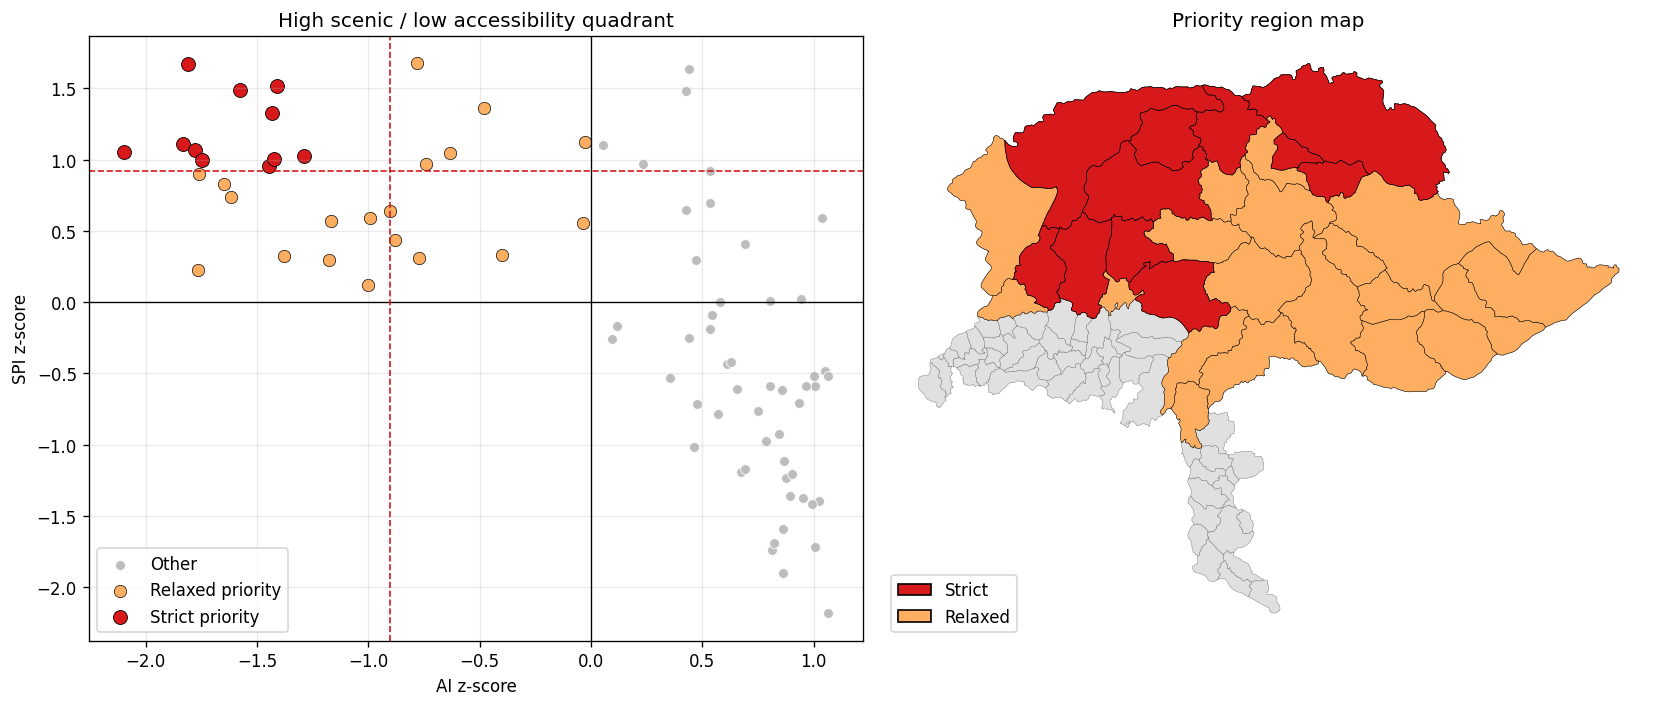

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(analysis_gdf['ai_z'], analysis_gdf['spi_z'], color='#bdbdbd', s=35, edgecolor='white', linewidth=0.5, label='Other')
strict = analysis_gdf['priority_strict']
relaxed_only = analysis_gdf['priority_relaxed'] & ~strict
ax.scatter(analysis_gdf.loc[relaxed_only, 'ai_z'], analysis_gdf.loc[relaxed_only, 'spi_z'], color='#fdae61', s=55, edgecolor='black', linewidth=0.4, label='Relaxed priority')
ax.scatter(analysis_gdf.loc[strict, 'ai_z'], analysis_gdf.loc[strict, 'spi_z'], color='#d7191c', s=70, edgecolor='black', linewidth=0.5, label='Strict priority')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axhline(spi_q75, color='#d7191c', linestyle='--', linewidth=1)
ax.axvline(ai_q25, color='#d7191c', linestyle='--', linewidth=1)
ax.set_xlabel('AI z-score')
ax.set_ylabel('SPI z-score')
ax.set_title('High scenic / low accessibility quadrant')
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1]
base = analysis_gdf.plot(color='#e0e0e0', linewidth=0.25, edgecolor='0.45', ax=ax)
analysis_gdf[analysis_gdf['priority_relaxed']].plot(color='#fdae61', linewidth=0.3, edgecolor='black', ax=ax)
analysis_gdf[analysis_gdf['priority_strict']].plot(color='#d7191c', linewidth=0.4, edgecolor='black', ax=ax)
ax.set_title('Priority region map')
ax.set_axis_off()
legend = [Patch(facecolor='#d7191c', edgecolor='black', label='Strict'), Patch(facecolor='#fdae61', edgecolor='black', label='Relaxed')]
ax.legend(handles=legend, loc='lower left')

plt.tight_layout()
savefig('06_priority_regions.png')
plt.show()

## 10. Component Contribution Analysis

The proposal asks how forest cover, water bodies, and terrain ruggedness contribute to scenic potential clustering. This section derives tehsil means from component rasters and relates them to tehsil SPI.

In [13]:
def raster_zonal_mean(raster_path, zones_gdf, label, respect_nodata=True):
    rows = []
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype('float32')
        nodata = src.nodata
        if respect_nodata and nodata is not None and np.isfinite(nodata):
            arr[arr == nodata] = np.nan
        if zones_gdf.crs != src.crs:
            zones = zones_gdf.to_crs(src.crs)
        else:
            zones = zones_gdf
        for idx, row in zones.iterrows():
            mask = geometry_mask([row.geometry], out_shape=arr.shape, transform=src.transform, invert=True)
            vals = arr[mask & np.isfinite(arr)]
            rows.append({
                'tehsil': row['tehsil'],
                f'{label}_mean': float(np.nanmean(vals)) if vals.size else np.nan,
                f'{label}_count': int(vals.size),
            })
    return pd.DataFrame(rows)

component_frames = [
    raster_zonal_mean(paths['tri'], analysis_gdf[['tehsil', 'geometry']].copy(), 'tri'),
    raster_zonal_mean(paths['forest'], analysis_gdf[['tehsil', 'geometry']].copy(), 'forest', respect_nodata=False),
    raster_zonal_mean(paths['water'], analysis_gdf[['tehsil', 'geometry']].copy(), 'water', respect_nodata=False),
    raster_zonal_mean(paths['snow'], analysis_gdf[['tehsil', 'geometry']].copy(), 'snow'),
]
components = component_frames[0]
for frame in component_frames[1:]:
    components = components.merge(frame, on='tehsil', how='outer')

# Binary masks are proportions when averaged. Snow is already frequency/proportion.
components['forest_pct'] = components['forest_mean'] * 100
components['water_pct'] = components['water_mean'] * 100
components['snow_pct'] = components['snow_mean'] * 100

analysis_gdf = analysis_gdf.merge(components, on='tehsil', how='left')
components.to_csv(outputs / 'component_zonal_statistics.csv', index=False)
display(analysis_gdf[['tehsil', 'tri_mean', 'forest_pct', 'water_pct', 'snow_pct', 'spi']].head())

,tehsil,tri_mean,forest_pct,water_pct,snow_pct,spi
0,BAGH,38.984833,36.196730,0.106821,5.520089,-0.103081
1,DHEERKOT,37.589561,20.416413,0.008693,2.992979,-0.366219
2,BARNALA,9.399435,21.499036,0.357025,0.036567,-0.666979
3,BHIMBER,13.636903,30.902788,0.013438,0.137583,-0.475282
4,SAMAHNI,21.258482,33.307391,0.000000,0.151465,-0.392897


,component,pearson_r,spearman_rho,ols_slope,ols_slope_p,ols_r_squared
0,tri_mean,0.844896,0.859282,0.019176,3.616483e-23,0.713850
1,forest_pct,0.128766,0.020958,0.002891,2.519378e-01,0.016581
2,water_pct,0.613695,0.689605,0.014550,1.116939e-09,0.376621
3,snow_pct,0.799379,0.862082,0.023058,3.691793e-19,0.639007


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\07_component_correlations.png


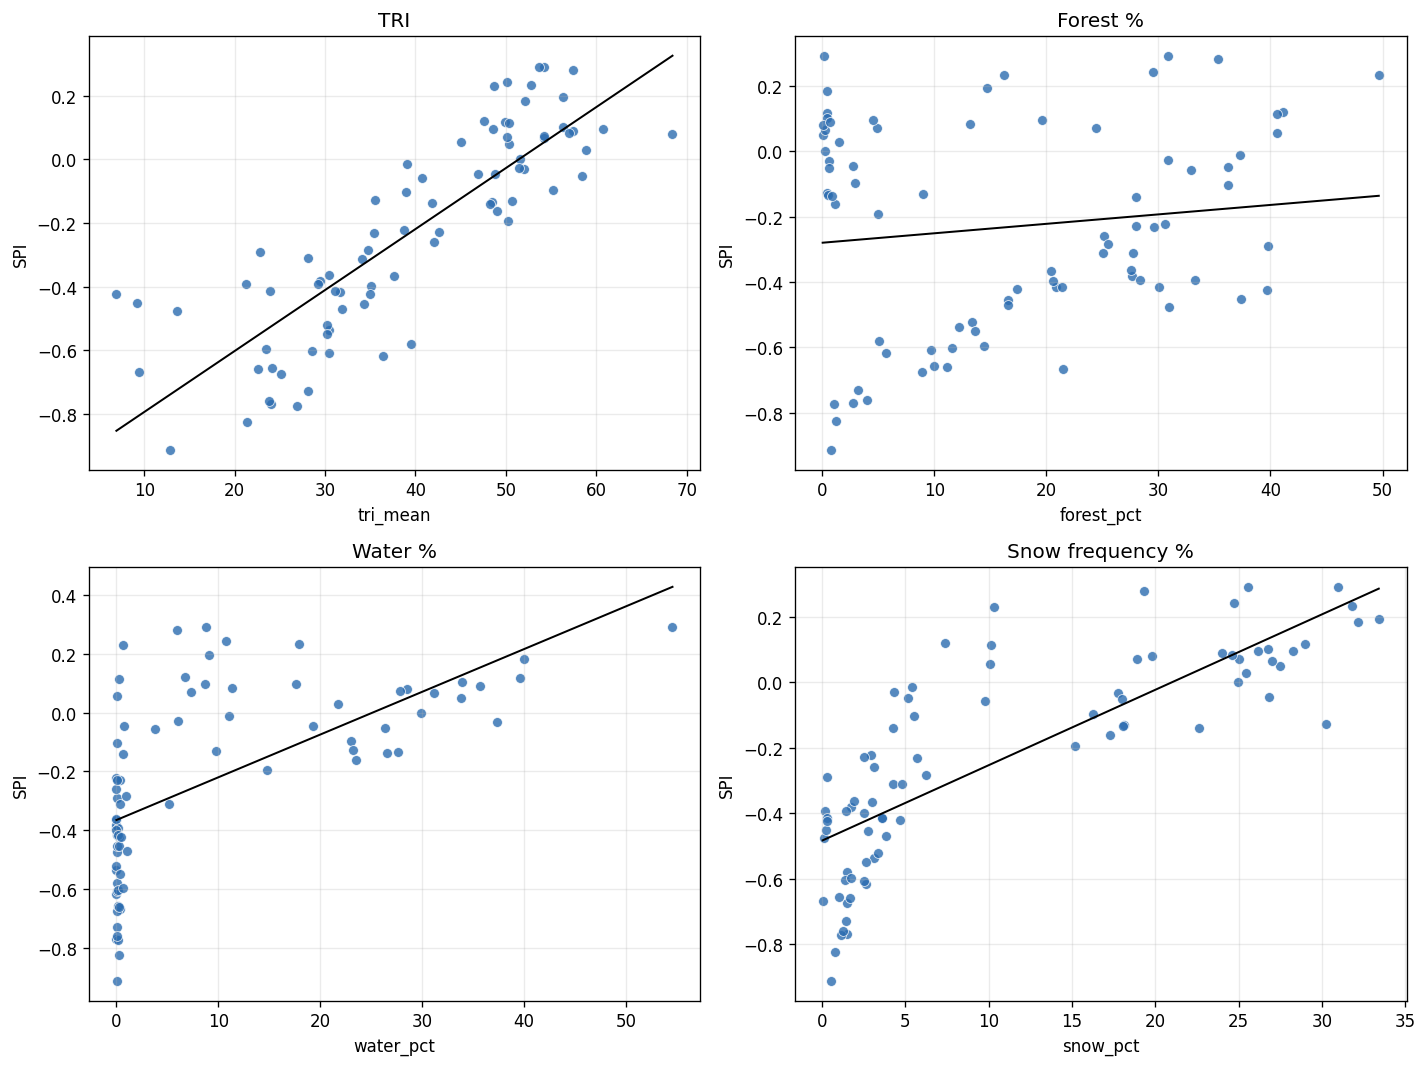

In [14]:
component_cols = ['tri_mean', 'forest_pct', 'water_pct', 'snow_pct']
corr_rows = []
for col in component_cols:
    valid = analysis_gdf[[col, 'spi']].dropna()
    X_comp = sm.add_constant(valid[col].astype(float))
    comp_model = sm.OLS(valid['spi'].astype(float), X_comp).fit()
    corr_rows.append({
        'component': col,
        'pearson_r': valid[[col, 'spi']].corr(method='pearson').iloc[0, 1],
        'spearman_rho': valid[[col, 'spi']].corr(method='spearman').iloc[0, 1],
        'ols_slope': comp_model.params[col],
        'ols_slope_p': comp_model.pvalues[col],
        'ols_r_squared': comp_model.rsquared,
    })
component_corr = pd.DataFrame(corr_rows)
component_corr.to_csv(outputs / 'component_spi_correlations.csv', index=False)
display(component_corr)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col, title in zip(axes.ravel(), component_cols, ['TRI', 'Forest %', 'Water %', 'Snow frequency %']):
    ax.scatter(analysis_gdf[col], analysis_gdf['spi'], s=35, alpha=0.8, color='#2B6CB0', edgecolor='white', linewidth=0.5)
    valid = analysis_gdf[[col, 'spi']].dropna()
    if len(valid) > 2 and valid[col].nunique() > 1:
        comp_model = sm.OLS(valid['spi'].astype(float), sm.add_constant(valid[col].astype(float))).fit()
        xs = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(xs, comp_model.params['const'] + comp_model.params[col] * xs, color='black', linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('SPI')
    ax.grid(alpha=0.25)
plt.tight_layout()
savefig('07_component_correlations.png')
plt.show()

## 11. Sensitivity Analysis for SPI Weighting

This implements the proposal's suggested alternative weighting schemes using tehsil-level component metrics. All weight sets sum to 1:

- Proposal weights: `0.40 TRI + 0.25 Forest + 0.20 Water + 0.15 Snow`
- Equal weights: `0.25 each`
- Terrain-emphasized: `0.50 TRI + 0.20 Forest + 0.15 Water + 0.15 Snow`
- Vegetation/water-emphasized: `0.30 TRI + 0.30 Forest + 0.25 Water + 0.15 Snow`


In [15]:
for col in component_cols:
    analysis_gdf[f'{col}_z'] = zscore(analysis_gdf[col])

weight_sets = {
    'proposal': {'tri_mean_z': 0.40, 'forest_pct_z': 0.25, 'water_pct_z': 0.20, 'snow_pct_z': 0.15},
    'equal': {'tri_mean_z': 0.25, 'forest_pct_z': 0.25, 'water_pct_z': 0.25, 'snow_pct_z': 0.25},
    'terrain_emphasis': {'tri_mean_z': 0.50, 'forest_pct_z': 0.20, 'water_pct_z': 0.15, 'snow_pct_z': 0.15},
    'vegetation_water_emphasis': {'tri_mean_z': 0.30, 'forest_pct_z': 0.30, 'water_pct_z': 0.25, 'snow_pct_z': 0.15},
}

for name, weights in weight_sets.items():
    total_weight = sum(weights.values())
    if not np.isclose(total_weight, 1.0):
        raise ValueError(f'{name} weights sum to {total_weight:.3f}, expected 1.0')

for name, weights in weight_sets.items():
    score = np.zeros(len(analysis_gdf), dtype='float64')
    for col, w in weights.items():
        score += analysis_gdf[col].fillna(0).to_numpy() * w
    analysis_gdf[f'spi_sens_{name}'] = score
    analysis_gdf[f'gap_sens_{name}'] = zscore(score) - analysis_gdf['ai_z']
    analysis_gdf[f'priority_sens_{name}'] = (zscore(score) > 0) & (analysis_gdf['ai_z'] < 0)

sens_rows = []
base_priority = set(analysis_gdf.loc[analysis_gdf['priority_relaxed'], 'tehsil'])
for name in weight_sets:
    score_col = f'spi_sens_{name}'
    priority_col = f'priority_sens_{name}'
    corr_with_current = analysis_gdf[['spi', score_col]].corr(method='pearson').iloc[0, 1]
    priority_set = set(analysis_gdf.loc[analysis_gdf[priority_col], 'tehsil'])
    jaccard = len(base_priority & priority_set) / len(base_priority | priority_set) if (base_priority | priority_set) else np.nan
    sens_rows.append({
        'weight_set': name,
        'corr_with_current_spi': corr_with_current,
        'priority_count': int(analysis_gdf[priority_col].sum()),
        'priority_overlap_with_current_relaxed': len(base_priority & priority_set),
        'priority_jaccard_with_current_relaxed': jaccard,
    })

sensitivity_summary = pd.DataFrame(sens_rows)
sensitivity_summary.to_csv(outputs / 'sensitivity_summary.csv', index=False)
display(sensitivity_summary)

priority_stability_cols = ['tehsil', 'priority_relaxed'] + [f'priority_sens_{name}' for name in weight_sets]
priority_stability = analysis_gdf[priority_stability_cols].copy()
priority_stability['priority_frequency'] = priority_stability.drop(columns='tehsil').sum(axis=1)
analysis_gdf['priority_frequency'] = priority_stability['priority_frequency'].values
priority_stability = priority_stability.sort_values('priority_frequency', ascending=False)
priority_stability.to_csv(outputs / 'priority_stability_by_weight_set.csv', index=False)
display(priority_stability.head(20))

,weight_set,corr_with_current_spi,priority_count,priority_overlap_with_current_relaxed,priority_jaccard_with_current_relaxed
0,proposal,0.975303,30,30,1.0
1,equal,0.972344,30,30,1.0
2,terrain_emphasis,0.953385,30,30,1.0
3,vegetation_water_emphasis,0.990420,30,30,1.0


,tehsil,priority_relaxed,priority_sens_proposal,priority_sens_equal,priority_sens_terrain_emphasis,priority_sens_vegetation_water_emphasis,priority_frequency
13,ATHUMQAM,True,True,True,True,True,5
12,MUZAFFARABAD,True,True,True,True,True,5
34,ISHKOMEN,True,True,True,True,True,5
35,PUNIAL,True,True,True,True,True,5
36,YASIN,True,True,True,True,True,5
37,GILGIT,True,True,True,True,True,5
38,ALIABAD,True,True,True,True,True,5
39,GOJAL,True,True,True,True,True,5
40,NAGAR-I,True,True,True,True,True,5
41,NAGAR-II,True,True,True,True,True,5


Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\08_sensitivity_analysis.png


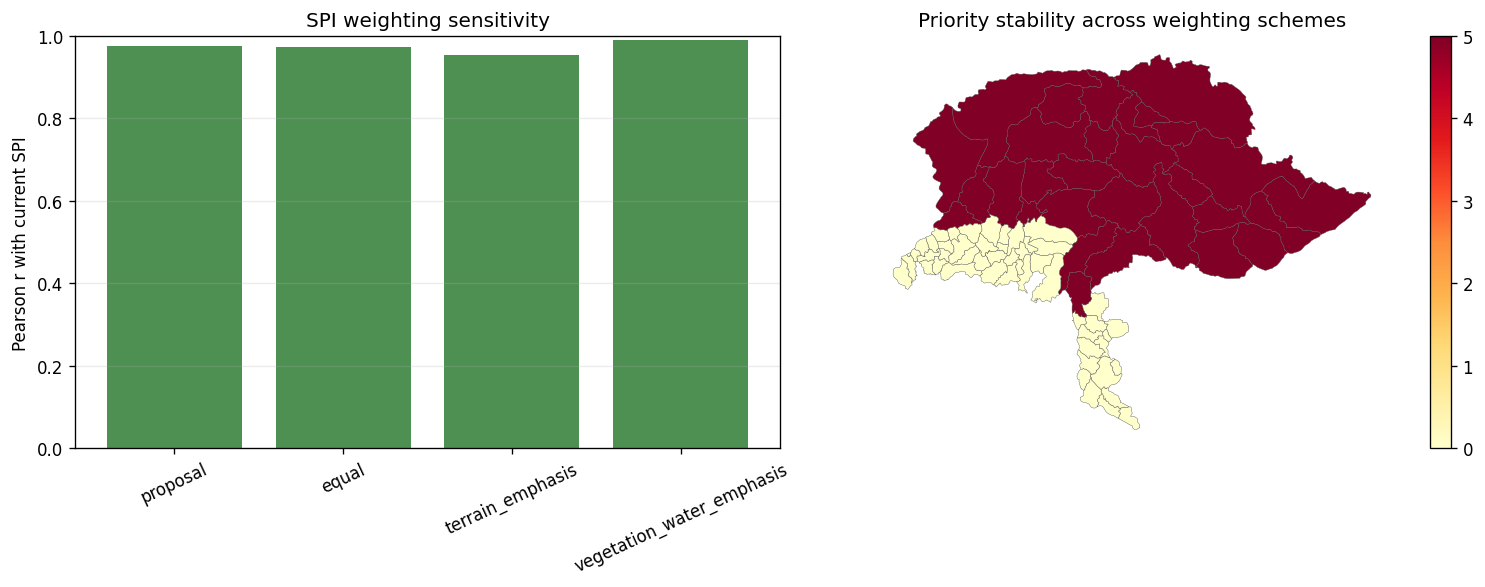

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(sensitivity_summary['weight_set'], sensitivity_summary['corr_with_current_spi'], color='#2E7D32', alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel('Pearson r with current SPI')
ax.set_title('SPI weighting sensitivity')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)

ax = axes[1]
analysis_gdf.plot(column='priority_frequency', cmap='YlOrRd', linewidth=0.25, edgecolor='0.35', legend=True, ax=ax)
ax.set_title('Priority stability across weighting schemes')
ax.set_axis_off()

plt.tight_layout()
savefig('08_sensitivity_analysis.png')
plt.show()

## 12. Bivariate SPI-AI Map

This map classifies tehsils by low/medium/high SPI and low/medium/high AI, helping identify scenic-accessibility combinations at a glance.

Saved: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\09_bivariate_spi_ai_map.png


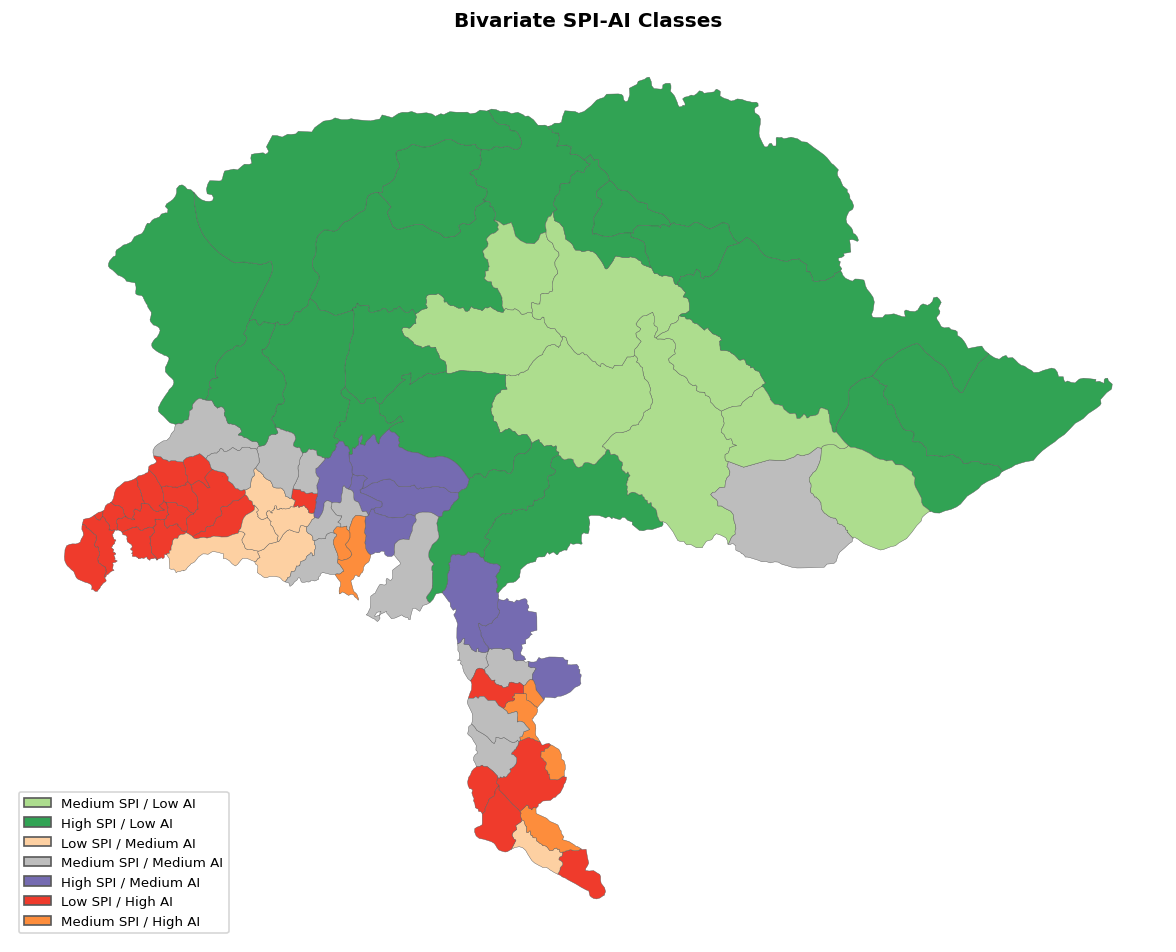

In [17]:
def tertile_label(series):
    q1, q2 = series.quantile([1/3, 2/3])
    return pd.cut(series, bins=[-np.inf, q1, q2, np.inf], labels=['Low', 'Medium', 'High'])

analysis_gdf['spi_class'] = tertile_label(analysis_gdf['spi'])
analysis_gdf['ai_class'] = tertile_label(analysis_gdf['ai'])
analysis_gdf['bivariate_class'] = analysis_gdf['spi_class'].astype(str) + ' SPI / ' + analysis_gdf['ai_class'].astype(str) + ' AI'

bivar_colors = {
    'Low SPI / Low AI': '#d9f0d3',
    'Medium SPI / Low AI': '#addd8e',
    'High SPI / Low AI': '#31a354',
    'Low SPI / Medium AI': '#fdd0a2',
    'Medium SPI / Medium AI': '#bdbdbd',
    'High SPI / Medium AI': '#756bb1',
    'Low SPI / High AI': '#ef3b2c',
    'Medium SPI / High AI': '#fd8d3c',
    'High SPI / High AI': '#54278f',
}

fig, ax = plt.subplots(figsize=(10, 8))
colors = analysis_gdf['bivariate_class'].map(bivar_colors)
analysis_gdf.plot(color=colors, linewidth=0.25, edgecolor='0.35', ax=ax)
ax.set_title('Bivariate SPI-AI Classes', fontweight='bold')
ax.set_axis_off()
handles = [Patch(facecolor=color, edgecolor='0.35', label=label) for label, color in bivar_colors.items() if label in set(analysis_gdf['bivariate_class'])]
ax.legend(handles=handles, loc='lower left', fontsize=8, frameon=True)
plt.tight_layout()
savefig('09_bivariate_spi_ai_map.png')
plt.show()

## 13. Export Final Statistical Dataset

The exported GeoJSON and CSV contain tehsil-level SPI/AI values, z-scores, Moran/LISA outputs, OLS residuals, priority flags, component metrics, and sensitivity results.

In [18]:
final_geojson = outputs / 'tehsil_spi_ai_statistical_analysis.geojson'
final_csv = outputs / 'tehsil_spi_ai_statistical_analysis.csv'

analysis_gdf.to_file(final_geojson, driver='GeoJSON')
analysis_gdf.drop(columns='geometry').to_csv(final_csv, index=False)

report = {
    'n_tehsils': int(len(analysis_gdf)),
    'moran': global_moran.to_dict(orient='records'),
    'ols': regression_summary.set_index('metric')['value'].to_dict(),
    'priority_counts': {
        'strict': int(analysis_gdf['priority_strict'].sum()),
        'relaxed': int(analysis_gdf['priority_relaxed'].sum()),
        'lisa_gap': int(analysis_gdf['priority_lisa_gap'].sum()),
    },
    'outputs_dir': str(outputs),
}
with open(outputs / 'analysis_summary.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f'Saved final GeoJSON: {final_geojson}')
print(f'Saved final CSV: {final_csv}')
print(f'Saved summary JSON: {outputs / "analysis_summary.json"}')
print('Notebook analysis complete.')

Saved final GeoJSON: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\tehsil_spi_ai_statistical_analysis.geojson
Saved final CSV: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\tehsil_spi_ai_statistical_analysis.csv
Saved summary JSON: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\statistical_analysis\analysis_summary.json
Notebook analysis complete.
